In [ ]:
#uploading virufy datste from git
!git clone https://github.com/virufy/virufy-data.git

fatal: destination path 'virufy-data' already exists and is not an empty directory.


In [ ]:
virufy_path = "/content/virufy-data/clinical/segmented"

In [ ]:
#uploading cough detection dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
kaggle_path = "/content/drive/MyDrive/COUGH_CLASS_DATASET"

In [ ]:
#VERIFICATION
import os

print("Kaggle folders:", os.listdir(kaggle_path))
print("Virufy sample files:", os.listdir(virufy_path)[:5])

Kaggle folders: ['final_data_v3.csv', 'Smote_data.csv', 'data_new_extended.csv', 'cough_dataset.csv', 'cough_trial_extended.csv', 'Smote_data_1.csv', 'with_delta_data_raw.csv', 'trial_covid', 'MelSpectograms']
Virufy sample files: ['pos', 'neg']


**COMBININIG & CREATING BALANCED DATASET**

In [ ]:
import os

final_path = "/content/drive/MyDrive/final_dataset"
covid_path = os.path.join(final_path, "covid")
noncovid_path = os.path.join(final_path, "non_covid")

os.makedirs(covid_path, exist_ok=True)
os.makedirs(noncovid_path, exist_ok=True)

In [ ]:
import shutil

virufy_path = "/content/virufy-data/clinical/segmented"

# COVID (pos)
for file in os.listdir(os.path.join(virufy_path, "pos")):
    if file.endswith(".wav"):
        src = os.path.join(virufy_path, "pos", file)
        shutil.copy(src, covid_path)

# NON-COVID (neg)
for file in os.listdir(os.path.join(virufy_path, "neg")):
    if file.endswith(".wav"):
        src = os.path.join(virufy_path, "neg", file)
        shutil.copy(src, noncovid_path)

print("Virufy added")

Virufy added


In [ ]:
import os
import shutil
import pandas as pd

# Paths
csv_path = os.path.join(kaggle_path, "cough_dataset.csv")
audio_folder = os.path.join(kaggle_path, "trial_covid")

# Load CSV
df = pd.read_csv(csv_path)

copied = 0
missing = 0

for _, row in df.iterrows():

    filename = row["file"]          # already has .wav
    label = str(row["status"]).lower()

    full_path = os.path.join(audio_folder, filename)

    if os.path.exists(full_path):

        # Label mapping
        if label == "covid":
            dst = covid_path
        else:
            dst = noncovid_path

        shutil.copy(full_path, dst)
        copied += 1

    else:
        missing += 1

print("Copied:", copied)
print("Missing:", missing)

Copied: 164
Missing: 586


In [ ]:
print("After adding COUGH COVID DATASET:")
print("COVID:", len(os.listdir(covid_path)))
print("NON-COVID:", len(os.listdir(noncovid_path)))

After adding COUGH COVID DATASET:
COVID: 149
NON-COVID: 147


**AUGMENTATION ON COVID SMAPLES**

In [ ]:
import librosa
import numpy as np
import soundfile as sf
import os
import random

covid_path  ="/content/drive/MyDrive/final_dataset/covid"

def augment_audio(file_path, save_path, idx):
    y, sr = librosa.load(file_path, sr=22050)

    # 1. Add noise
    noise = np.random.randn(len(y))
    y_noise = y + 0.005 * noise

    # 2. Pitch shift
    y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=2)

    # 3. Time stretch
    y_stretch = librosa.effects.time_stretch(y, rate=1.1)

    base = os.path.basename(file_path).replace(".wav", "")

    sf.write(f"{save_path}/{base}_noise_{idx}.wav", y_noise, sr)
    sf.write(f"{save_path}/{base}_pitch_{idx}.wav", y_pitch, sr)
    sf.write(f"{save_path}/{base}_stretch_{idx}.wav", y_stretch, sr)

In [ ]:
#applyign augmentation here
covid_files = os.listdir(covid_path)

target_size = len(os.listdir(noncovid_path))  # match non-covid
current_size = len(covid_files)

print("Current COVID:", current_size)
print("Target COVID:", target_size)

i = 0

while len(os.listdir(covid_path)) < target_size:
    file = random.choice(covid_files)
    file_path = os.path.join(covid_path, file)

    augment_audio(file_path, covid_path, i)
    i += 1

Current COVID: 149
Target COVID: 147


In [ ]:
#NUMBER OF SAMPLES(bALANCED NOW!)
print("FINAL DATASET:")
print("COVID:", len(os.listdir(covid_path)))
print("NON-COVID:", len(os.listdir(noncovid_path)))

FINAL DATASET:
COVID: 149
NON-COVID: 147


In [ ]:
#SAVEDD FINAL AUGMENTATED BALANCED DATSET TO DRIVE
import os

drive_path = "/content/drive/MyDrive/final_dataset"

print("Saved dataset:")
print("COVID:", len(os.listdir(os.path.join(drive_path, "covid"))))
print("NON-COVID:", len(os.listdir(os.path.join(drive_path, "non_covid"))))

Saved dataset:
COVID: 149
NON-COVID: 147


**IMPROVEMENTS**

**RUN FROM HERE AFTER RESTART**

In [1]:
from google.colab import drive
drive.mount('/content/drive')
base_path ="/content/drive/MyDrive/final_dataset"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

print(os.listdir(base_path))

['covid', 'non_covid']


AUDIO TO SPECTOGRAM


Audio shape: (8192,)
Sampling rate: 16000


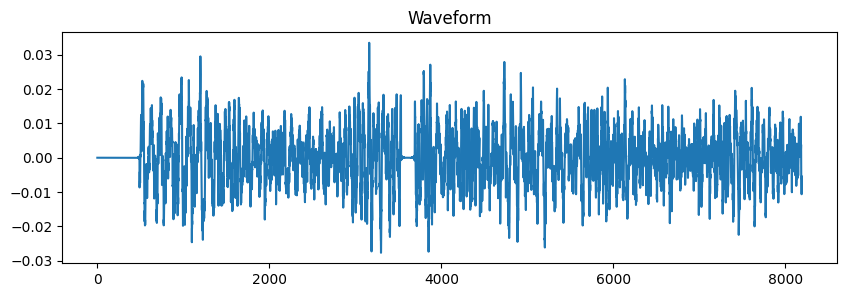

In [3]:
import librosa
import librosa.display
import numpy as np
import os
import matplotlib.pyplot as plt

file_path = "/content/drive/MyDrive/final_dataset/covid/" + os.listdir("/content/drive/MyDrive/final_dataset/covid")[0]

y, sr = librosa.load(file_path, sr=16000)

print("Audio shape:", y.shape)
print("Sampling rate:", sr)

plt.figure(figsize=(10, 3))
plt.plot(y)
plt.title("Waveform")
plt.show()

In [4]:
#CONVERT TO MEL SPECTOGRAM
def extract_mel_spectrogram(file_path):
    try:
        y, sr = librosa.load(file_path, sr=16000)

        # Remove empty audio
        if len(y) == 0:
            return None

        # Create Mel Spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_mels=128,
            fmax=8000
        )

        # Add epsilon BEFORE log
        mel_spec = mel_spec + 1e-8

        # Convert to log scale
        log_mel_spec = librosa.power_to_db(mel_spec)
        log_mel_spec = np.clip(log_mel_spec, -80, 80)

        return log_mel_spec

    except:
        return None

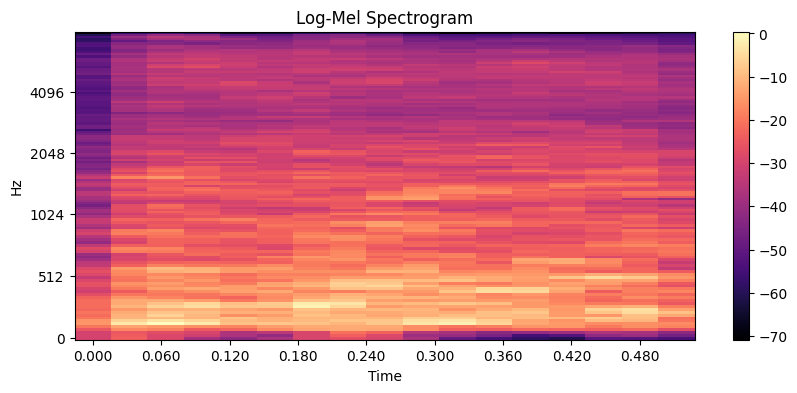

In [5]:
#JUST VISUAL
spec = extract_mel_spectrogram(file_path)

plt.figure(figsize=(10, 4))
librosa.display.specshow(spec, sr=16000, x_axis='time', y_axis='mel')
plt.colorbar()
plt.title("Log-Mel Spectrogram")
plt.show()

In [6]:
#FIXING SIZE TO PASS THIS AS INPUT FEATURE FOR CNN MODEL
def pad_or_truncate(spec, max_len=128):
    if spec.shape[1] < max_len:
        pad_width = max_len - spec.shape[1]
        spec = np.pad(spec, pad_width=((0,0),(0,pad_width)), mode='constant')
    else:
        spec = spec[:, :max_len]

    return spec
#DATASET CREATIONS
data = []
labels = []

for label in ["covid", "non_covid"]:
    folder = os.path.join(base_path, label)

    for file in os.listdir(folder):
        if file.endswith(".wav"):
            file_path = os.path.join(folder, file)

            spec = extract_mel_spectrogram(file_path)

            if spec is None:
                continue

            spec = pad_or_truncate(spec)

            if np.isnan(spec).any() or np.isinf(spec).any():
                continue

            data.append(spec)
            labels.append(1 if label == "covid" else 0)

In [7]:
X = np.array(data)
y = np.array(labels)

print("New dataset shape:", X.shape)

New dataset shape: (296, 128, 128)


LOADING DATA->**AND NORMALIZATION OF SPECTOGRAMS**

In [8]:

#ADDING NEW CHANNEL
X = X[..., None]

#VERIFICATION BEFORE
print("Max value:", np.max(X))
print("Min value:", np.min(X))
print("Any NaN:", np.isnan(X).any())

# CORRECT NORMALIZATION (Z-score)
mean = np.mean(X)
std = np.std(X)

X = (X - mean) / (std + 1e-8)

# VERIFY AFTER
print("After normalization:")
print("Max:", np.max(X))
print("Min:", np.min(X))
print("Any NaN:", np.isnan(X).any())


Max value: 39.840782
Min value: -74.473526
Any NaN: False
After normalization:
Max: 3.443329
Min: -2.5215144
Any NaN: False


In [9]:
import torch
from torch.utils.data import Dataset

class CoughDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [10]:
#FIX SHAPE
import numpy as np

# Convert (N, 128, 128, 1) → (N, 1, 128, 128)
X = np.transpose(X, (0, 3, 1, 2))

print("New X shape:", X.shape)
#LOADING AND SPLITTING DATSET
dataset = CoughDataset(X, y)
from torch.utils.data import DataLoader, random_split

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

New X shape: (296, 1, 128, 128)
Train batches: 13
Test batches: 3


**BUILDING CNN+LSTM MODEL**

In [11]:
print(X.shape)
print(y.shape)

(296, 1, 128, 128)
(296,)


In [12]:
import torch
import torch.nn as nn

class CNN_LSTM(nn.Module):
    def __init__(self):
        super(CNN_LSTM, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Dropout(0.2),

            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Dropout(0.2),

            nn.Conv2d(64, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )

        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=64,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.cnn(x)

        B, C, H, W = x.size()

        x = x.view(B, C, H*W)
        x = x.permute(0, 2, 1)

        x, _ = self.lstm(x)

        x = x[:, -1, :]

        x = self.fc(x)

        return x

TRAINING & TESTING


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN_LSTM().to(device)
print("Model loaded on:", device)

Model loaded on: cuda


In [14]:
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001,weight_decay=1e-5)#THIS IS L2 REGULARIZATION

In [15]:
#TRAINING WITH EARLY STOPPING
#SAVING THE BEST MODEL
num_epochs = 30

best_val_loss = float('inf')
patience = 5
counter = 0
best_epoch = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1)

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

        preds = (torch.sigmoid(outputs) > 0.58).float()
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    total_loss = total_loss / total
    train_acc = correct / total
    train_losses.append(total_loss)

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(1)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item() * X_batch.size(0)

    val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1} | Train Loss: {total_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}")

    # -------- EARLY STOPPING --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        counter = 0
        torch.save(model.state_dict(), "/content/drive/MyDrive/best_model.pth")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

Epoch 1 | Train Loss: 0.6887 | Train Acc: 0.5072 | Val Loss: 0.6742
Epoch 2 | Train Loss: 0.6493 | Train Acc: 0.5990 | Val Loss: 0.6372
Epoch 3 | Train Loss: 0.6443 | Train Acc: 0.6377 | Val Loss: 0.6243
Epoch 4 | Train Loss: 0.6229 | Train Acc: 0.6329 | Val Loss: 0.6264
Epoch 5 | Train Loss: 0.6136 | Train Acc: 0.6522 | Val Loss: 0.6168
Epoch 6 | Train Loss: 0.5942 | Train Acc: 0.6667 | Val Loss: 0.6122
Epoch 7 | Train Loss: 0.5841 | Train Acc: 0.6812 | Val Loss: 0.6004
Epoch 8 | Train Loss: 0.5602 | Train Acc: 0.7198 | Val Loss: 0.5827
Epoch 9 | Train Loss: 0.5553 | Train Acc: 0.7391 | Val Loss: 0.6018
Epoch 10 | Train Loss: 0.5407 | Train Acc: 0.7633 | Val Loss: 0.5480
Epoch 11 | Train Loss: 0.4814 | Train Acc: 0.8309 | Val Loss: 0.5063
Epoch 12 | Train Loss: 0.4491 | Train Acc: 0.8213 | Val Loss: 0.4626
Epoch 13 | Train Loss: 0.4348 | Train Acc: 0.8116 | Val Loss: 0.4552
Epoch 14 | Train Loss: 0.3911 | Train Acc: 0.8502 | Val Loss: 0.4660
Epoch 15 | Train Loss: 0.3386 | Train Acc: 


Best Validation Loss: 0.1610625602982261
Best Epoch: 27
SAVED model loaded!


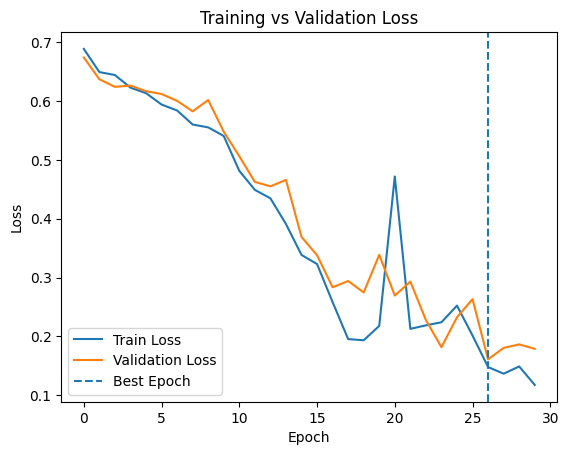

In [16]:
#RESULTS OF TRAINING
print("\nBest Validation Loss:", best_val_loss)
print("Best Epoch:", best_epoch)

# -------- LOAD BEST MODEL --------
torch.save(model.state_dict(), "/content/drive/MyDrive/best_model.pth")
print("SAVED model loaded!")

# -------- VISUAL RESULTS --------
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.axvline(best_epoch-1, linestyle='--', label="Best Epoch")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

LOADING BEST MODEL SAVED IN DRIVE AND **TESTING**

In [17]:
model = CNN_LSTM().to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pth"))
model.eval()

CNN_LSTM(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(64, 64, batch_first=True)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [18]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1)

        outputs = model(X_batch)

        preds = (torch.sigmoid(outputs) > 0.58).float()

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

test_acc = correct / total
print("Test Accuracy:", test_acc)

Test Accuracy: 0.9333333333333333


**PERFORMANCE METRICS**

Confusion Matrix:
 [[18  3]
 [ 0 24]]


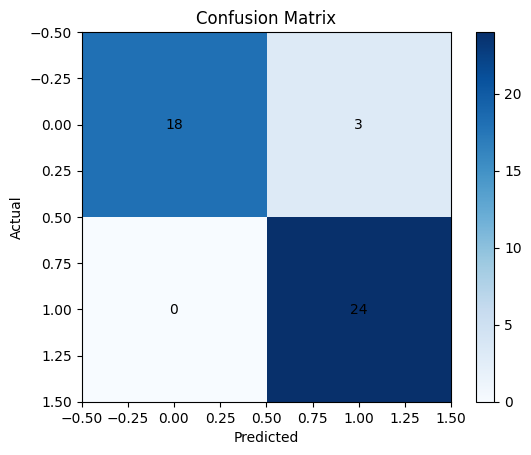


Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.86      0.92        21
         1.0       0.89      1.00      0.94        24

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



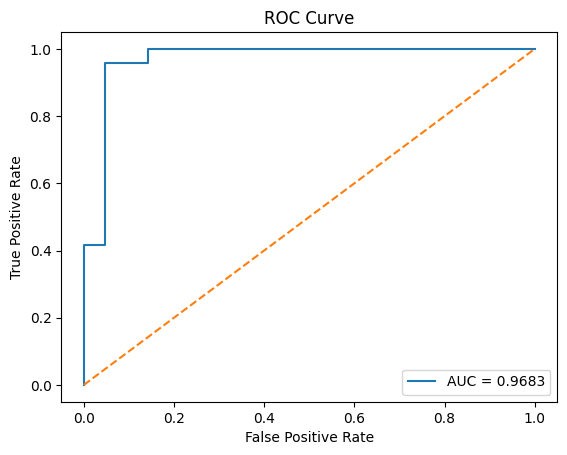

In [19]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1)

        outputs = model(X_batch)

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Convert to numpy
all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()
all_probs = np.array(all_probs).flatten()

# ---------------- CONFUSION MATRIX ----------------
cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix:\n", cm)

plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

# ---------------- CLASSIFICATION REPORT ----------------
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

# ---------------- ROC CURVE ----------------
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()